In [79]:
import glob
import fitsio
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])  

In [80]:
systematics_list = ['H_Alpha', 'Stellar_Density_AllWISE', 'CSFD', 'EBV','PSFDEPTH_Z','PSFDEPTH_G','PSFDEPTH_R','PSFSIZE_G','PSFSIZE_R','PSFSIZE_Z','H_Alpha_Good','PSFDEPTH_Z_RAW','PSFDEPTH_G_RAW','PSFDEPTH_R_RAW']

In [81]:
path = '/user/animesh.sah/DESI_PECVEL/notebooks/imaging_systematics_maps/data/'
mask =hp.read_map(f'{path}/full_mask_nside_64_for_systmatics_20M.fits')
randoms_counts = hp.read_map(f'{path}/full_counts_randoms_nside_64.fits')

In [82]:
systematics_maps = {}
for sys_name in systematics_list:
    sys_map = hp.read_map(f'{path}/full_{sys_name}_nside_64.fits')
    systematics_maps[sys_name] = sys_map

In [74]:
def points_to_map(ra_deg, dec_deg, nside, weights=None):
    theta = np.radians(90.0 - dec_deg)  
    phi   = np.radians(ra_deg)
    ipix  = hp.ang2pix(nside, theta, phi, nest=False)
    npix  = hp.nside2npix(nside)
    if weights is None:
        weights = np.ones_like(ipix, dtype=np.float64)
    m = np.bincount(ipix, weights=weights, minlength=npix).astype(np.float64)
    return m
data = Table(fitsio.FITS('../table_match_final.fits')[1].read())
data = points_to_map(data['RA'], data['DEC'], nside=64)


In [90]:
max_count = randoms_counts[mask==1].max()
normalized_counts = randoms_counts / max_count
randoms_counts_subtracted =np.where(normalized_counts>0.25, randoms_counts, 0)

num_outside = len(normalized_counts[mask==1][normalized_counts[mask==1]<0.25])
print(f'Number of pixels outside 0.25: {num_outside}, out of {len(normalized_counts[mask==1])} total pixels')

data_counts_subtracted = np.where(normalized_counts>0.25, data, 0)



Number of pixels outside 0.25: 446, out of 21344 total pixels


In [91]:
def plot_systematic_relation(ngal, nran, features, num_bins=50, ax=None, **kwargs):
    """
    Plot the relationship between a systematic feature and galaxy density.

    Parameters
    ----------
    ngal : array-like
        Galaxy counts per pixel
    nran : array-like
        Random counts (weights) per pixel
    features : array-like
        Feature values (e.g., E(B-V), seeing, etc.)
    num_bins : int, optional
        Number of bins for equal-population binning (default: 50)
    ax : matplotlib.axes.Axes, optional
        Axes to plot on. If None, creates new figure.
    **kwargs : dict
        Additional keyword arguments passed to plt.plot()

    Returns
    -------
    bin_centers : array
        Center values of each bin
    normed_vals : array
        Normalized galaxy density in each bin
    """
    # Use numpy's percentile for equal-population binning
    bin_edges = np.nanpercentile(features, np.linspace(0, 100, num_bins+1))

    # Compute histograms
    rands, _ = np.histogram(features, bins=bin_edges, weights=nran)
    data, _ = np.histogram(features, bins=bin_edges, weights=ngal)

    # Compute normalized values
    norm_factor = rands.sum() / data.sum()
    normed_vals = (data / rands) * norm_factor

    # Bin centers
    bin_centers = (bin_edges[1:] + bin_edges[:-1]) / 2.0

    # Plot
    if ax is None:
        plt.figure()
        ax = plt.gca()

    ax.plot(bin_centers[:], normed_vals[:], 'k-', alpha=0.5, **kwargs)
    ax.plot(bin_centers[:], normed_vals[:], 'k.', **kwargs)

    ax.axhline(y=1.0, color='k', linestyle=':', alpha=0.5)
    ax.grid(linestyle='--', alpha=0.3)

    return bin_centers, normed_vals

In [92]:
ngal = data_counts_subtracted[mask==1]
nran = randoms_counts_subtracted[mask==1]

/tmp/ipykernel_1078766/2678207953.py:46: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(bin_centers[:], normed_vals[:], 'k-', alpha=0.5, **kwargs)
/tmp/ipykernel_1078766/2678207953.py:47: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  ax.plot(bin_centers[:], normed_vals[:], 'k.', **kwargs)
/tmp/ipykernel_1078766/2678207953.py:36: RuntimeWarning: invalid value encountered in divide
  normed_vals = (data / rands) * norm_factor


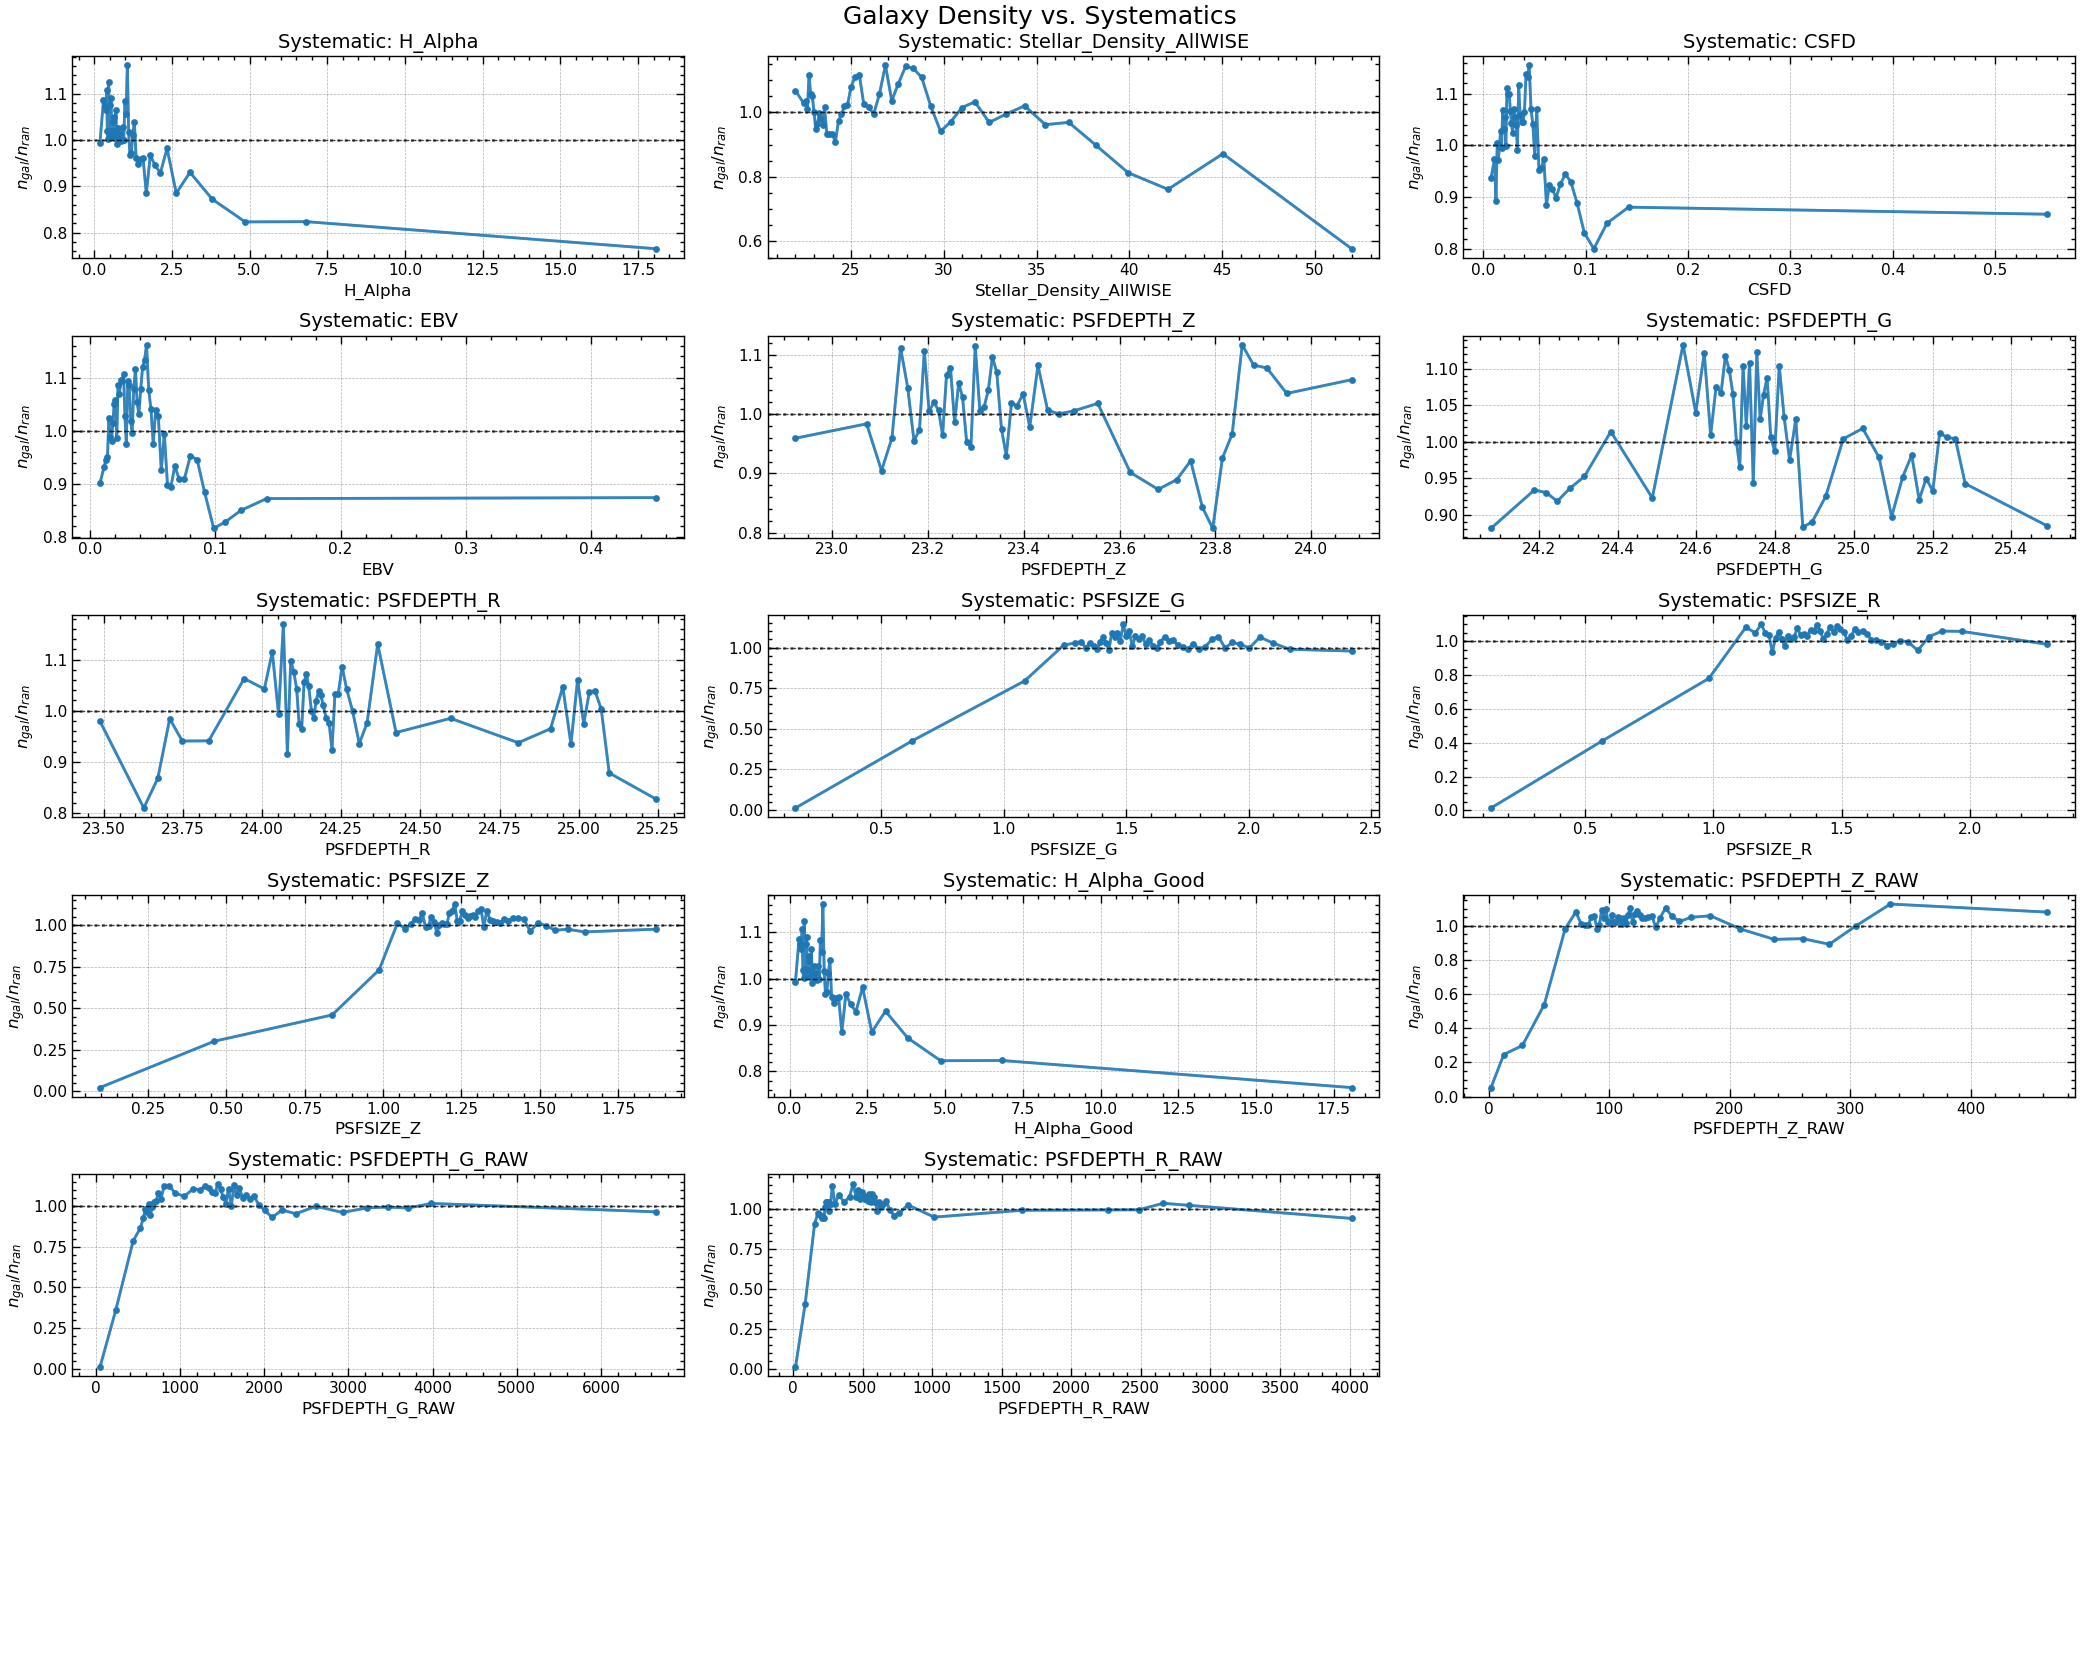

In [93]:
fig, axes = plt.subplots(6, 3, figsize=(21, 17))
axes = axes.flatten()

for idx, sys_name in enumerate(systematics_list):
    ax = axes[idx]
    bin_centers, normed_vals = plot_systematic_relation(
        ngal, nran, systematics_maps[sys_name][mask==1], ax=ax, color='tab:blue'
    )
    ax.plot(bin_centers, normed_vals, 'o-', markersize=4, color='tab:blue', alpha=0.8)
    ax.axhline(y=1.0, color='k', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_title(f'Systematic: {sys_name}', fontsize=14)
    ax.set_xlabel(sys_name, fontsize=12)
    ax.set_ylabel('$n_{gal} / n_{ran}$', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.grid(True, linestyle='--', alpha=0.3)

for ax in axes[len(systematics_list):]:
    ax.axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.95)
fig.suptitle('Galaxy Density vs. Systematics', fontsize=18)
plt.show()


In [94]:
psfsizez_map = np.where((mask == 1) & (systematics_maps['PSFSIZE_Z'] == 0), np.nan, systematics_maps['PSFSIZE_Z'])
psfsizeg_map = np.where((mask == 1) & (systematics_maps['PSFSIZE_G'] == 0), np.nan, systematics_maps['PSFSIZE_G'])
psfsizer_map = np.where((mask == 1) & (systematics_maps['PSFSIZE_R'] == 0), np.nan, systematics_maps['PSFSIZE_R'])


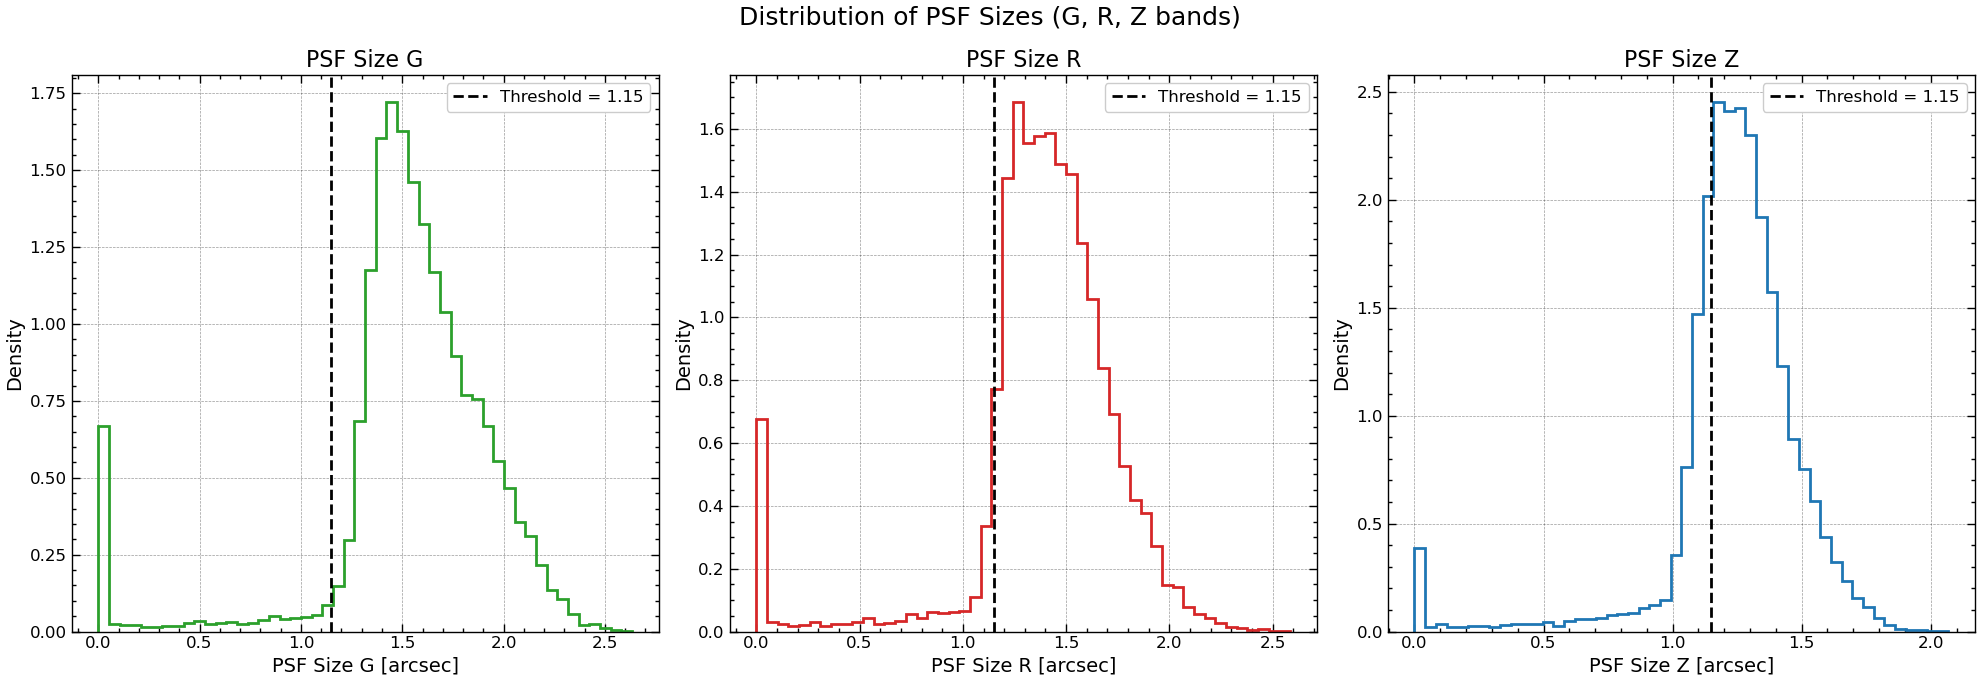

In [95]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes = axes.flatten()
vlines = [1.15, 1.15, 1.15]

psf_systematics = [name for name in systematics_list if 'PSFSIZE' in name]
colors = ['tab:green', 'tab:red', 'tab:blue']
titles = ['PSF Size G', 'PSF Size R', 'PSF Size Z']
xlabels = ['PSF Size G [arcsec]', 'PSF Size R [arcsec]', 'PSF Size Z [arcsec]']

for idx, sys_name in enumerate(psf_systematics):
    data_to_plot = systematics_maps[sys_name][mask==1]
    valid = np.isfinite(data_to_plot) & (data_to_plot != -1.6375e30)

    axes[idx].hist(data_to_plot[valid], bins=50, histtype='step', density=True, color=colors[idx], linewidth=2)
    axes[idx].set_title(titles[idx], fontsize=16)
    axes[idx].set_xlabel(xlabels[idx], fontsize=14)
    axes[idx].set_ylabel('Density', fontsize=14)
    axes[idx].axvline(x=vlines[idx], color='k', linestyle='--', linewidth=2, label=f'Threshold = {vlines[idx]}')
    axes[idx].legend(fontsize=12)
    axes[idx].tick_params(axis='both', which='major', labelsize=12)
    axes[idx].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.suptitle('Distribution of PSF Sizes (G, R, Z bands)', fontsize=18)
plt.show()

/tmp/ipykernel_1078766/2678207953.py:46: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(bin_centers[:], normed_vals[:], 'k-', alpha=0.5, **kwargs)
/tmp/ipykernel_1078766/2678207953.py:47: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k." (-> color='k'). The keyword argument will take precedence.
  ax.plot(bin_centers[:], normed_vals[:], 'k.', **kwargs)


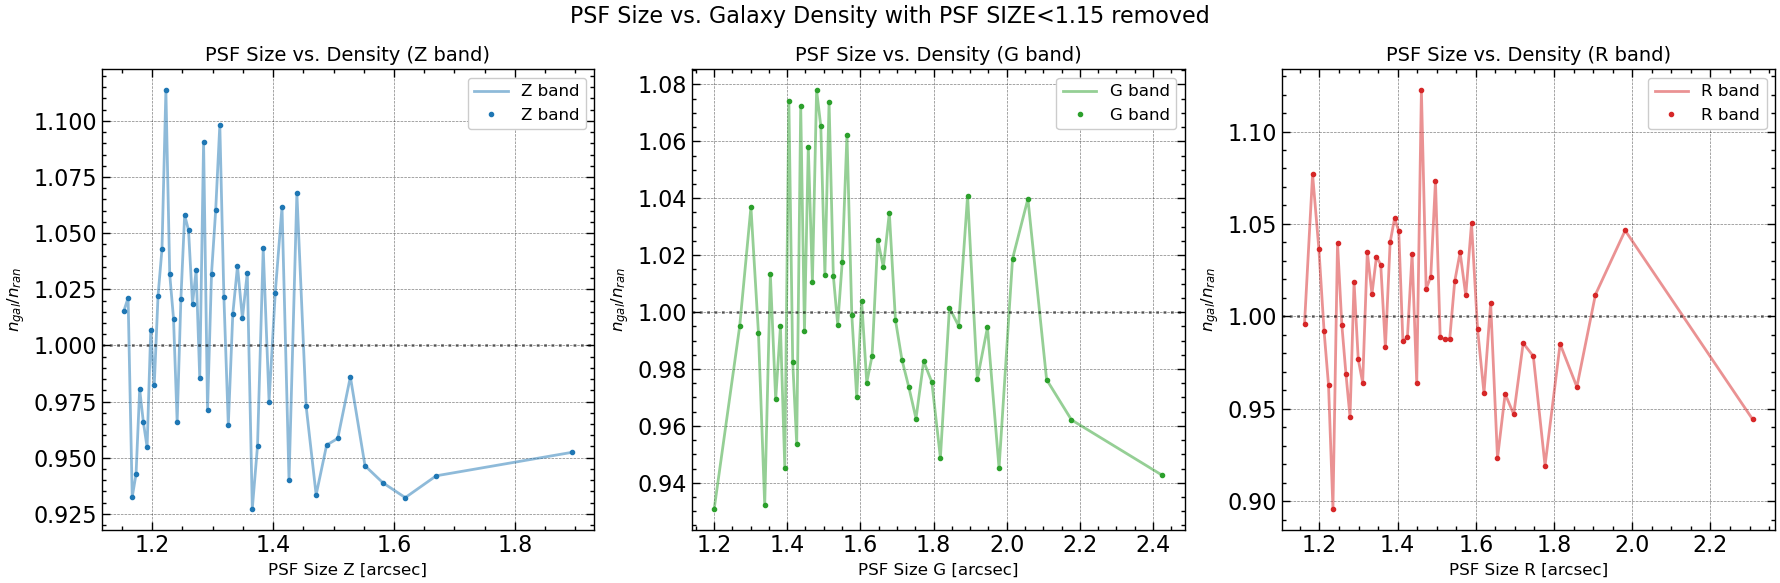

In [11]:

threshold = 1.15
mask_size_g = (mask == 1) & (systematics_maps['PSFSIZE_G'] > threshold)
mask_size_r =  (mask == 1) & (systematics_maps['PSFSIZE_R'] > threshold)
mask_size_z = (mask == 1) & (systematics_maps['PSFSIZE_Z'] > threshold)




fig, axes = plt.subplots(1, 3, figsize=(18, 6))
# Z band
ngal_z = data_counts_subtracted[mask_size_z]
nran_z = randoms_counts_subtracted[mask_size_z]

# G band
ngal_g = data_counts_subtracted[mask_size_g]
nran_g = randoms_counts_subtracted[mask_size_g]

# R band
ngal_r = data_counts_subtracted[mask_size_r]
nran_r = randoms_counts_subtracted[mask_size_r]
# Z band
ax_z = axes[0]
bin_centers_z, normed_vals_z = plot_systematic_relation(
    ngal_z, nran_z, systematics_maps['PSFSIZE_Z'][mask_size_z], ax=ax_z, color='tab:blue', label='Z band'
)
ax_z.set_title('PSF Size vs. Density (Z band)', fontsize=14)
ax_z.set_xlabel('PSF Size Z [arcsec]', fontsize=12)
ax_z.set_ylabel('$n_{gal} / n_{ran}$', fontsize=12)
ax_z.legend(fontsize=12)
ax_z.grid(True, linestyle='--', alpha=0.5)

# G band
ax_g = axes[1]
bin_centers_g, normed_vals_g = plot_systematic_relation(
    ngal_g, nran_g, systematics_maps['PSFSIZE_G'][mask_size_g], ax=ax_g, color='tab:green', label='G band'
)
ax_g.set_title('PSF Size vs. Density (G band)', fontsize=14)
ax_g.set_xlabel('PSF Size G [arcsec]', fontsize=12)
ax_g.set_ylabel('$n_{gal} / n_{ran}$', fontsize=12)
ax_g.legend(fontsize=12)
ax_g.grid(True, linestyle='--', alpha=0.5)

# R band
ax_r = axes[2]
bin_centers_r, normed_vals_r = plot_systematic_relation(
    ngal_r, nran_r, systematics_maps['PSFSIZE_R'][mask_size_r], ax=ax_r, color='tab:red', label='R band'
)
ax_r.set_title('PSF Size vs. Density (R band)', fontsize=14)
ax_r.set_xlabel('PSF Size R [arcsec]', fontsize=12)
ax_r.set_ylabel('$n_{gal} / n_{ran}$', fontsize=12)
ax_r.legend(fontsize=12)
ax_r.grid(True, linestyle='--', alpha=0.5)
plt.suptitle(f'PSF Size vs. Galaxy Density with PSF SIZE<{threshold} removed', fontsize=16)
plt.tight_layout()
plt.show()


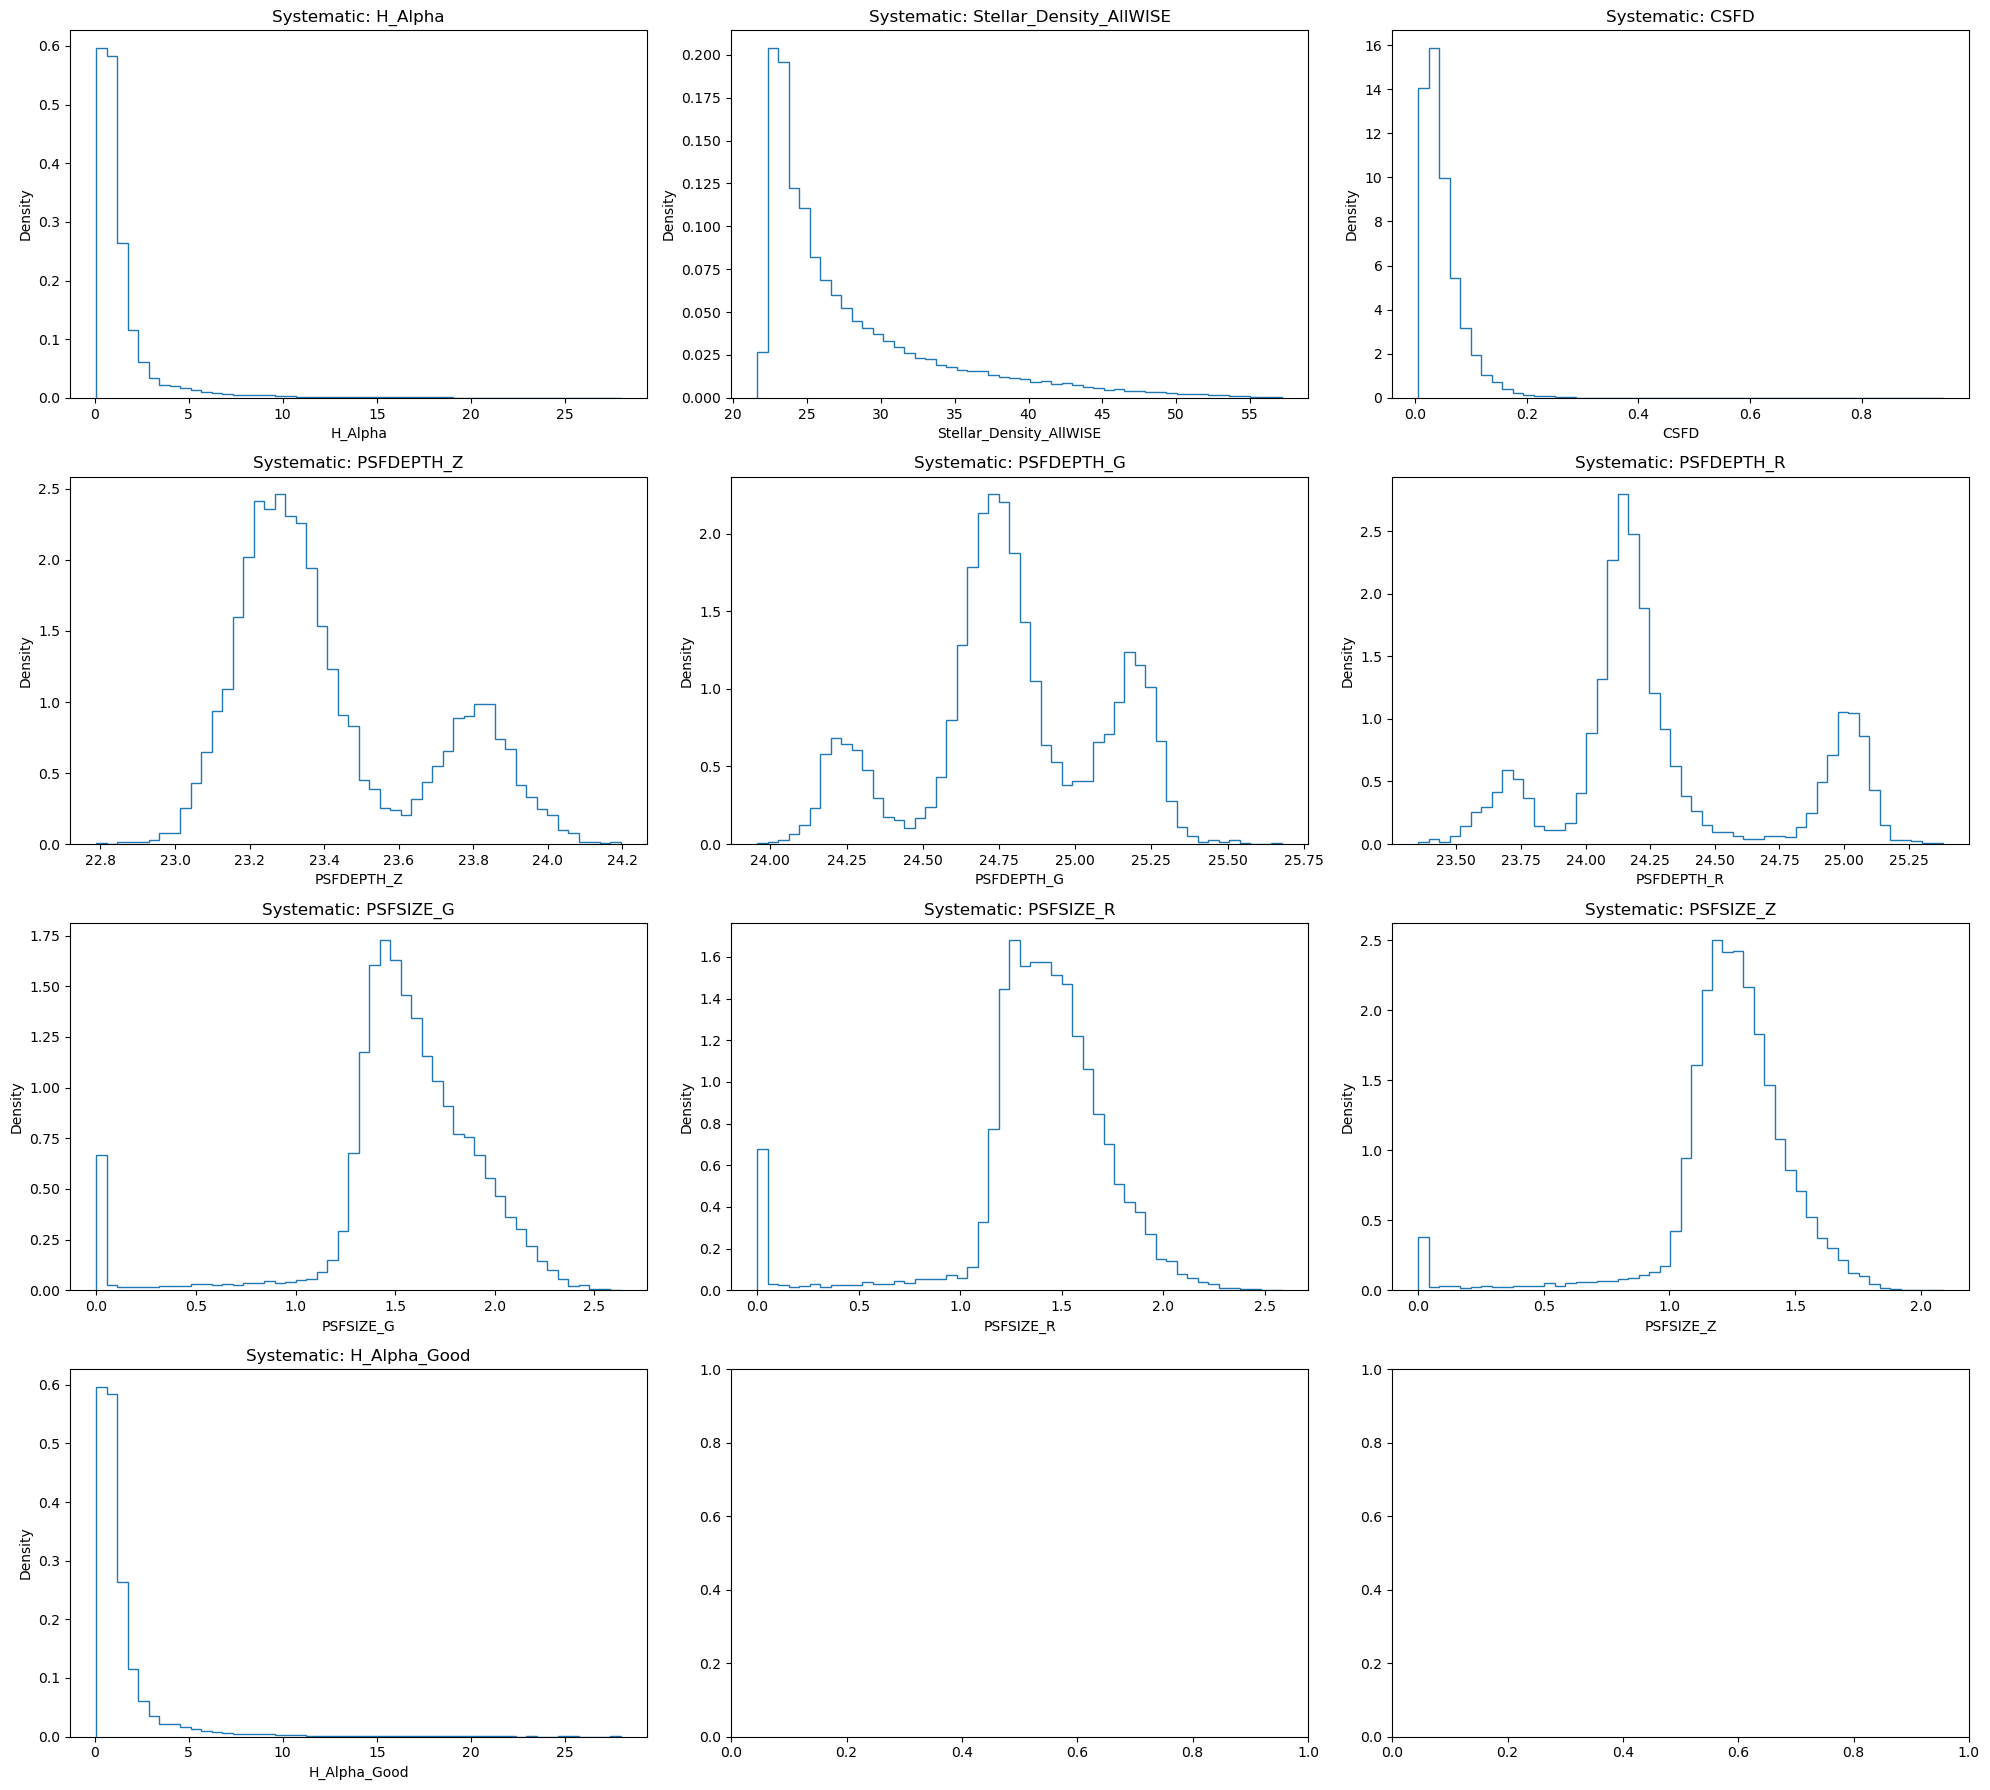

In [14]:
fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.flatten()

for idx, sys_name in enumerate(systematics_list):
    data_to_plot = systematics_maps[sys_name][mask==1]
    # Remove extreme values (e.g., -1.6375e30, nan)
    valid = np.isfinite(data_to_plot) & (data_to_plot != -1.6375e30)
    axes[idx].hist(data_to_plot[valid], bins=50, histtype='step', density=True)
    axes[idx].set_title(f'Systematic: {sys_name}')
    axes[idx].set_xlabel(sys_name)
    axes[idx].set_ylabel('Density')

plt.tight_layout()
plt.show()



In [27]:
systematics_list

['H_Alpha',
 'Stellar_Density_AllWISE',
 'CSFD',
 'EBV',
 'PSFDEPTH_Z',
 'PSFDEPTH_G',
 'PSFDEPTH_R',
 'PSFSIZE_G',
 'PSFSIZE_R',
 'PSFSIZE_Z',
 'H_Alpha_Good']

In [108]:
systematics_list_1 = ['PSFDEPTH_G', 'PSFDEPTH_R', 'PSFDEPTH_Z', 'PSFSIZE_G', 'PSFSIZE_R', 'PSFSIZE_Z', 'CSFD', 'Stellar_Density_AllWISE', 'H_Alpha']

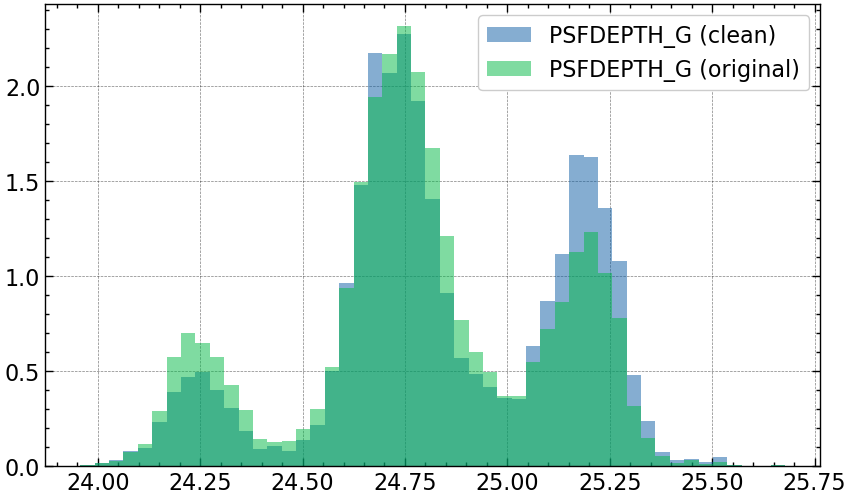

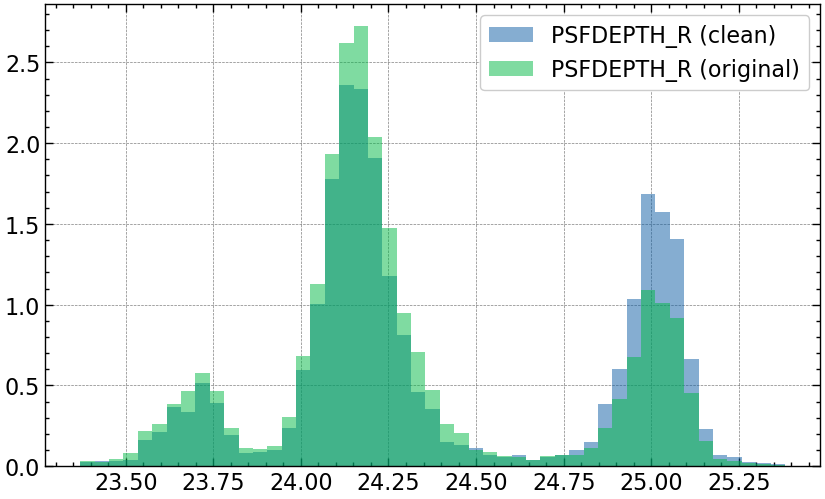

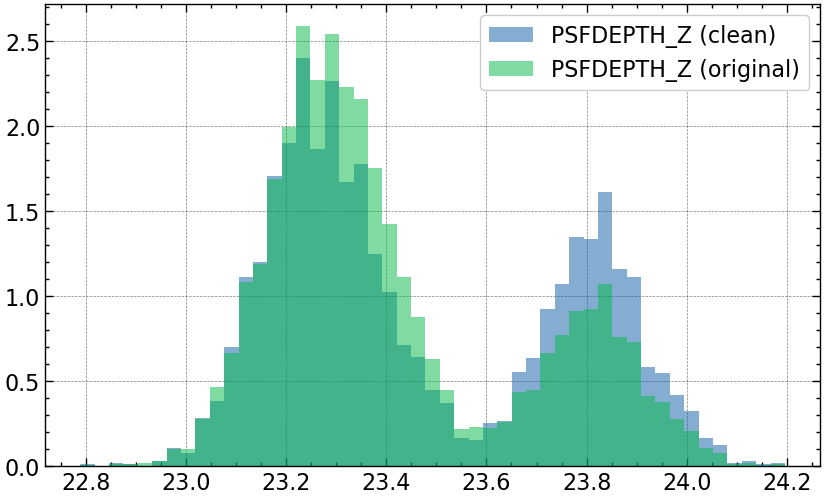

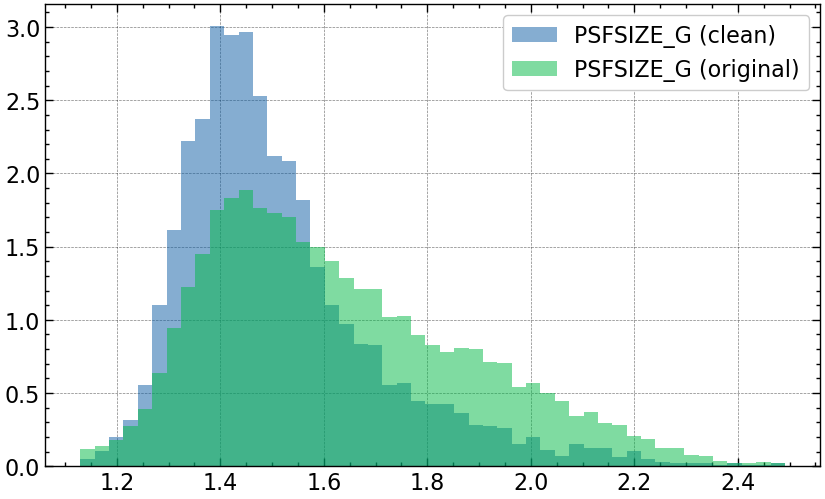

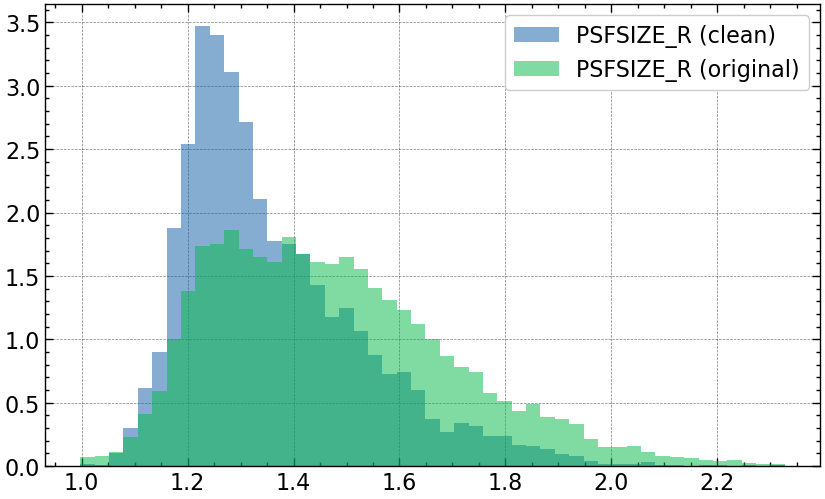

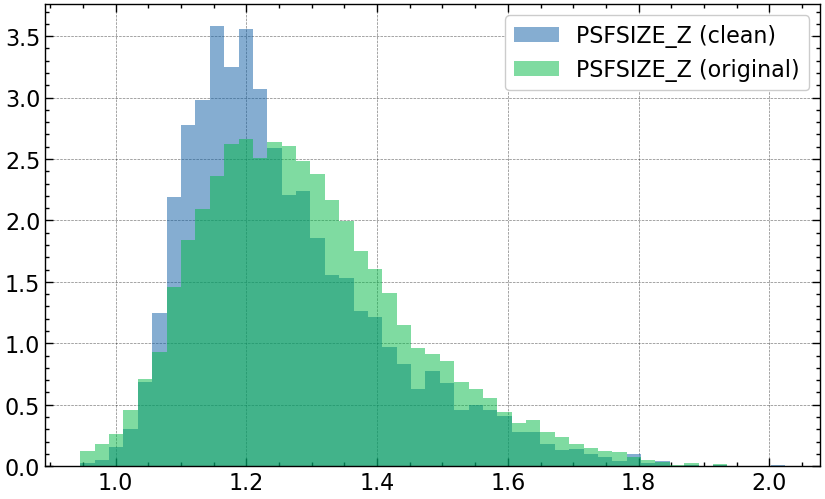

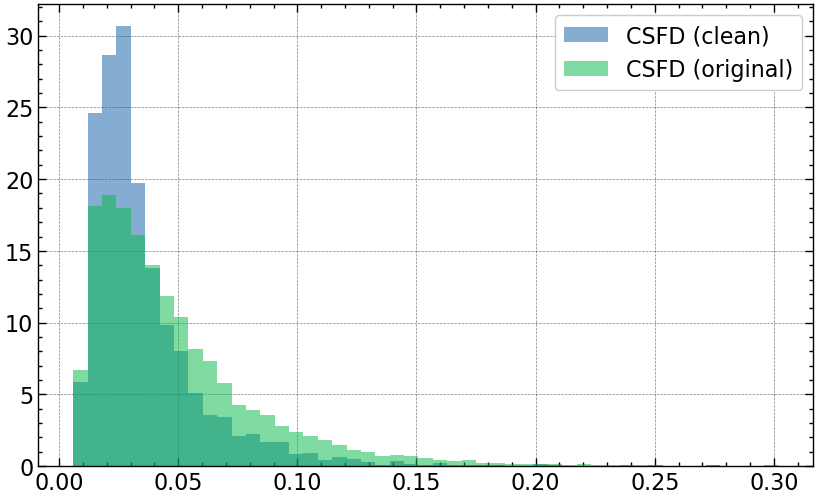

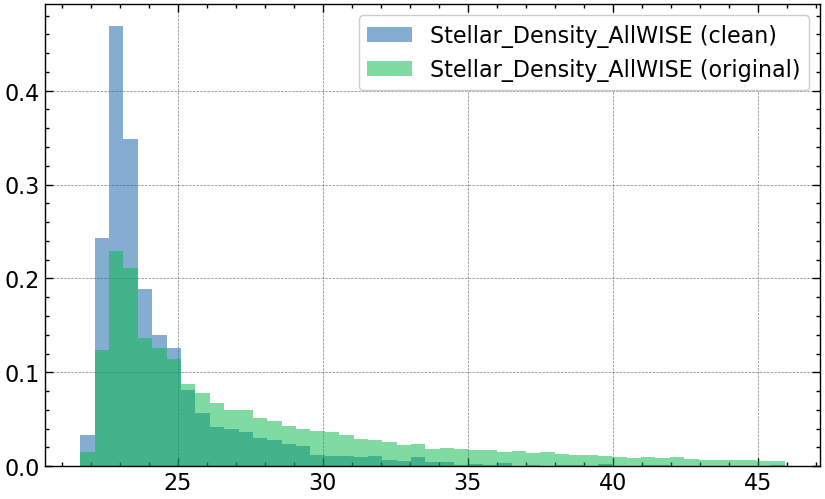

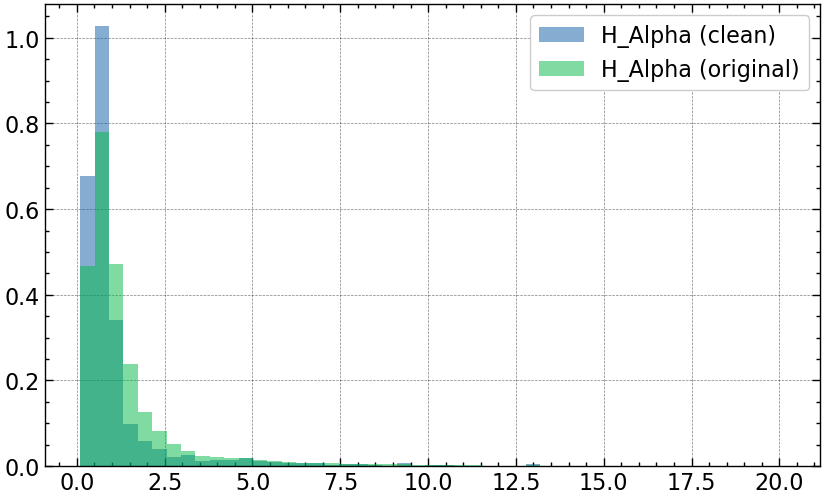

In [52]:
for i in range(X_clean.shape[1]):
    bins = np.linspace(X_clean[:, i].min(), X_clean[:, i].max(), 50)
    plt.figure(figsize=(10, 6))
    plt.hist(X_clean[:, i], bins=bins, alpha=0.5, label=systematics_list_1[i]+' (clean)',density=True)
    plt.hist(X[:, i], bins=bins, alpha=0.5, label=systematics_list_1[i]+' (original)',density=True)
    plt.legend()
    plt.show()

In [54]:
X[~mask_valid].shape

(17777, 9)

In [103]:
X.shape

(21344, 10)

In [102]:
X_clean.shape

(3598, 10)

In [100]:
for name in systematics_list:
    arr = systematics_maps[name][mask==1]
    num_nan = np.isnan(arr).sum()
    num_inf = np.isinf(arr).sum()
    print(f"{name}: nan={num_nan}, inf={num_inf} ,total={len(arr)}")

    #print(arr)

H_Alpha: nan=0, inf=0 ,total=21344
Stellar_Density_AllWISE: nan=0, inf=0 ,total=21344
CSFD: nan=0, inf=0 ,total=21344
EBV: nan=7, inf=0 ,total=21344
PSFDEPTH_Z: nan=15457, inf=0 ,total=21344
PSFDEPTH_G: nan=13770, inf=0 ,total=21344
PSFDEPTH_R: nan=15072, inf=0 ,total=21344
PSFSIZE_G: nan=7, inf=0 ,total=21344
PSFSIZE_R: nan=7, inf=0 ,total=21344
PSFSIZE_Z: nan=7, inf=0 ,total=21344
H_Alpha_Good: nan=0, inf=0 ,total=21344
PSFDEPTH_Z_RAW: nan=7, inf=0 ,total=21344
PSFDEPTH_G_RAW: nan=7, inf=0 ,total=21344
PSFDEPTH_R_RAW: nan=7, inf=0 ,total=21344


In [115]:
systematics_list_1 = [ 'CSFD']

In [116]:
# Prepare input features X for linear regression using all systematics in systematics_list
X = np.column_stack([systematics_maps[name][mask == 1] for name in systematics_list_1])
Y = data_counts_subtracted[mask == 1].reshape(-1, 1)


# Remove any row in X or Y that contains nan
mask_valid = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
num_removed = np.sum(~mask_valid)
print(f"Number of rows removed due to nan: {num_removed}")

X_clean = X[mask_valid]
Y_clean = Y[mask_valid]
scaler = StandardScaler()
Xn = scaler.fit_transform(X_clean)
reg = LinearRegression().fit(Xn, Y_clean)
y_pred = reg.predict(Xn)

y_pred_original = y_pred
print("y_pred range:", y_pred_original.min(), "to", y_pred_original.max())
print("Y range:", Y.min(), "to", Y.max())

Number of rows removed due to nan: 0
y_pred range: -28.210150088282223 to 24.982896409849904
Y range: 0.0 to 258.0


In [117]:
for name, coef in zip(systematics_list_1, reg.coef_[0]):
    print(name, round(coef,3))

CSFD -2.168


258.0

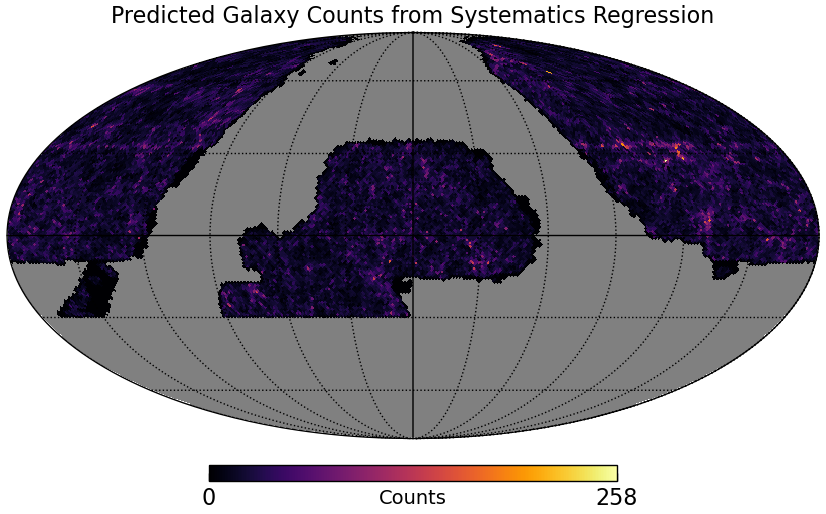

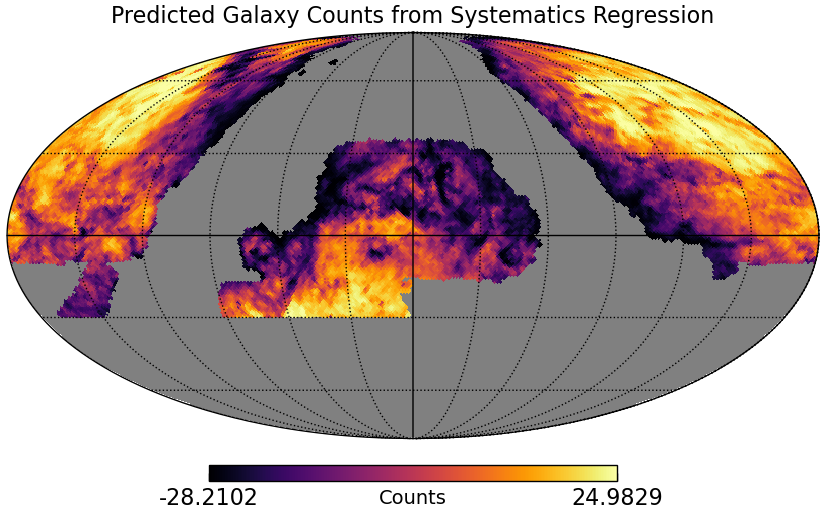

In [140]:
y= Y.ravel()
map = np.ones_like(mask)*hp.UNSEEN
map_indices = np.where(mask==1)[0][mask_valid]
map[map_indices] = y.ravel()
hp.mollview(map, title='Predicted Galaxy Counts from Systematics Regression', unit='Counts', cmap='inferno')
hp.graticule()

new_y_pred = y_pred.ravel()

map = np.ones_like(mask)*hp.UNSEEN
map_indices = np.where(mask==1)[0][mask_valid]
map[map_indices] = y_pred_original.ravel()
hp.mollview(map, title='Predicted Galaxy Counts from Systematics Regression', unit='Counts', cmap='inferno',norm='hist')
hp.graticule()


In [107]:
X = df_full[['PSFDEPTH_Z',
 'PSFDEPTH_G',
 'PSFDEPTH_R',
 'PSFSIZE_G',
 'PSFSIZE_R',
 'PSFSIZE_Z',
 'CSFD_EBV',
 'EBV'
 'STELLAR_DENSITY_ALLWISE',
 'H_ALPHA']][df_full['mask']==1].to_pandas().to_numpy()

X = df_full[[
 'CSFD_EBV',

]][df_full['mask']==1].to_pandas().to_numpy()
Y = df_full[['map']][df_full['mask']==1].to_pandas().to_numpy()

NameError: name 'df_full' is not defined

In [253]:
X_clean = X.copy()
X_clean[np.isinf(X_clean)] = np.nan

# Impute nan values with median (or mean)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_clean)

# Now apply StandardScaler
scaler = StandardScaler()
Xn = scaler.fit_transform(X_imputed)

In [255]:
reg = LinearRegression().fit(Xn, Y)
y_pred = reg.predict(Xn)

In [256]:
# y_pred is already in the original scale since Y was not transformed
# No inverse transformation needed
y_pred_original = y_pred
print("y_pred range:", y_pred_original.min(), "to", y_pred_original.max())
print("Y range:", Y.min(), "to", Y.max())

y_pred range: -2.2496481793063867 to 0.10906254297806862
Y range: -1.0 to 10.45638973915358


In [257]:
delta_sys = y_pred
print(delta_sys.min(), delta_sys.max(), delta_sys.std())

-2.2496481793063867 0.10906254297806862 0.09616572899738736


In [47]:
reg.coef_[0]

array([-0.09616573])

In [38]:
for name, coef in zip(cols, reg.coef_[0]):
    print(name, coef)

PSFDEPTH_Z 0.041106885914928004
PSFDEPTH_G 0.09526536323597547
PSFDEPTH_R -0.04499109353421261
PSFSIZE_G 0.10623337275919359
PSFSIZE_R 0.053712555346345045
PSFSIZE_Z 0.06741823533671976
CSFD_EBV -0.05235684213097314
STELLAR_DENSITY_ALLWISE -0.01130153013637303
H_ALPHA -0.01639289030769658


In [ ]:
# Recreate the plot of mean galaxy density / mean random density vs features
fig, axs = plt.subplots(6, 3, figsize=(12, 18))

# Define feature groups and labels
feature_groups = [
    ['CSFD_EBV', 'STELLAR_DENSITY_ALLWISE', 'H_ALPHA'],
    ['PSFDEPTH_R', 'PSFDEPTH_G', 'PSFDEPTH_Z'],
    ['PSFSIZE_R', 'PSFSIZE_G', 'PSFSIZE_Z']
]

x_labels = [
    ['E(B-V) [mag]', 'nstar [deg$^{-2}$]', 'H$\\alpha$'],
    ['Depth-r [mag]', 'Depth-g [mag]', 'Depth-z [mag]'],
    ['Seeing-r [arcsec]', 'Seeing-g [arcsec]', 'Seeing-z [arcsec]']
]

# Create bins for each feature
num_bins = 50

for i, feature_group in enumerate(feature_groups):
    for j, feature in enumerate(feature_group):
        ax = axs[i, j]
        
        # Get feature data for masked pixels
        features = df_full[feature][df_full['mask'] == 1]
        data = df_full['counts'][df_full['mask'] == 1]
        randoms = df_full['counts_randoms'][df_full['mask'] == 1]
        
        # Create bins
        bin_edges = np.linspace(np.nanmin(features), np.nanmax(features), num_bins + 1)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        
        # Compute mean galaxy density / mean random density in each bin
        normed_vals = np.zeros(num_bins)
        for k in range(num_bins):
            mask = (features >= bin_edges[k]) & (features < bin_edges[k+1])
            if np.sum(mask) > 0:
                mean_gal = np.mean(data[mask])
                mean_ran = np.mean(randoms[mask])
                if mean_ran > 0:
                    normed_vals[k] = mean_gal / mean_ran
                else:
                    normed_vals[k] = np.nan
        
        # Plot
        ax.plot(bin_centers, normed_vals, 'o-', markersize=3)
        ax.axhline(y=1, color='k', linestyle='--', alpha=0.5)
        ax.set_xlabel(x_labels[i][j])
        if j == 0:
            ax.set_ylabel('$\\bar n / \\bar n_{ran}$')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
# plt.show()

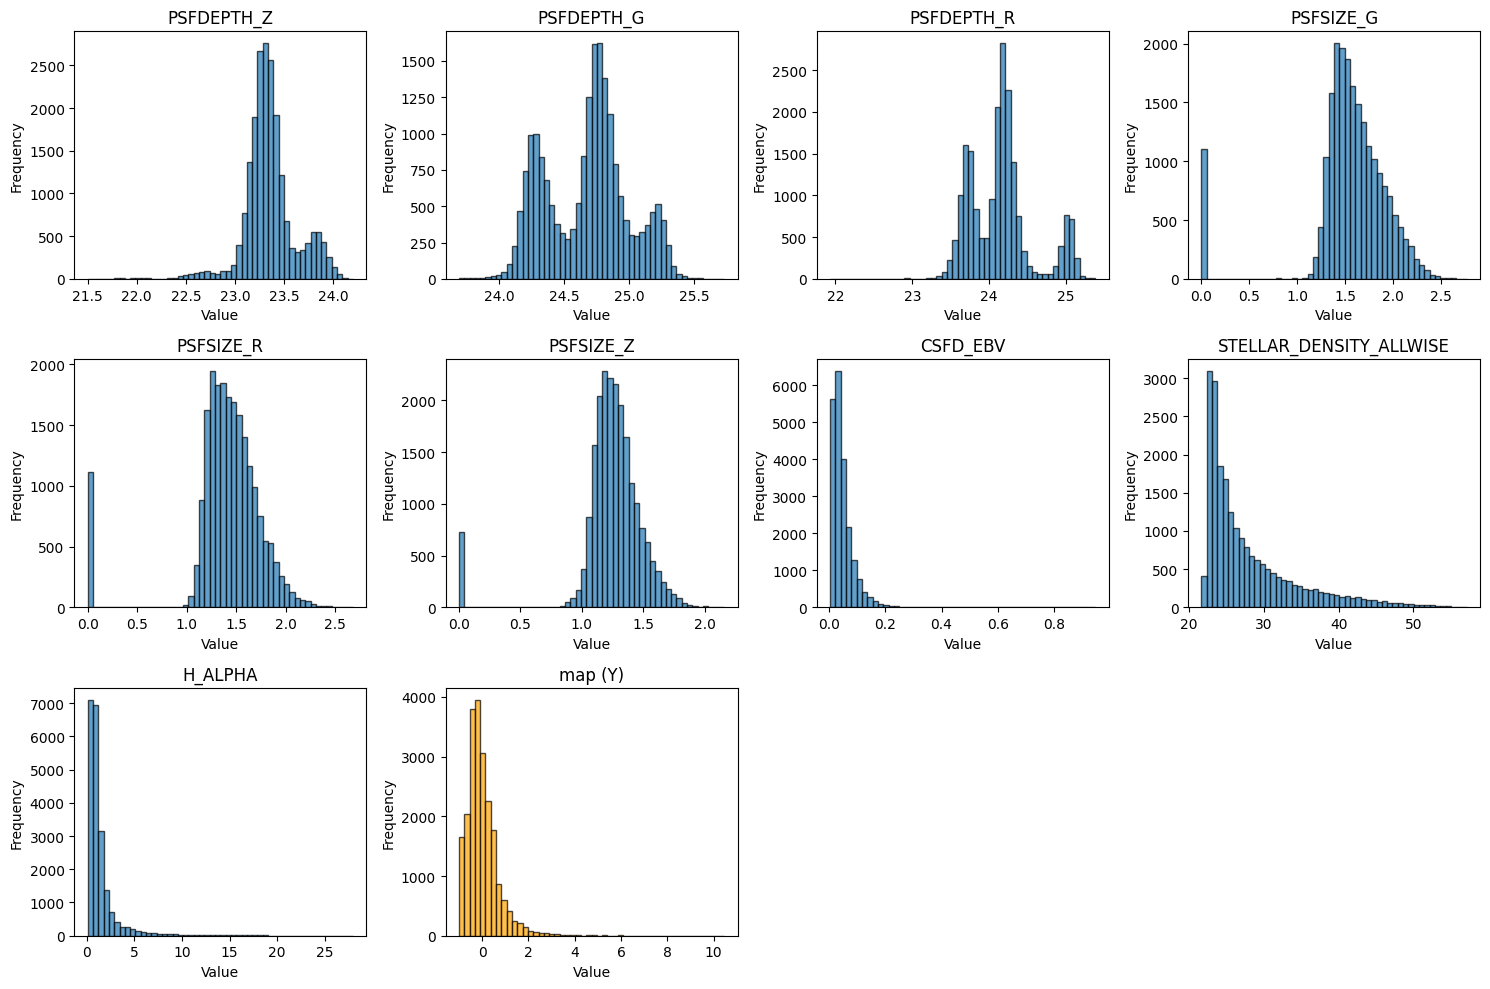

In [22]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

# Feature names
feature_names = ['PSFDEPTH_Z', 'PSFDEPTH_G', 'PSFDEPTH_R', 'PSFSIZE_G', 
                 'PSFSIZE_R', 'PSFSIZE_Z', 'CSFD_EBV', 'STELLAR_DENSITY_ALLWISE', 'H_ALPHA']

# Plot histogram for each feature in X
for i, feature_name in enumerate(feature_names):
    axes[i].hist(X[:, i][~np.isinf(X[:, i])], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(feature_name)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

# Plot histogram for Y
axes[9].hist(Y, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[9].set_title('map (Y)')
axes[9].set_xlabel('Value')
axes[9].set_ylabel('Frequency')

# Hide unused subplots
for i in range(10, 12):
    axes[i].axis('off')

plt.tight_layout()
plt.show()